# Unit09_Example_06 | 化工案例六：伴有輻射之平板穩態熱傳溫度分布 (BVP)

本 Notebook 以**含輻射散熱之一維平板穩態熱傳導問題**為例，
建立含非線性輻射項（ $T^4$ ）的**兩點邊界值問題 (BVP)**，
並使用 `scipy.integrate.solve_bvp()` 求解溫度沿板厚之分布。

## 目錄

- [§0 環境設定](#0)
- [§1 載入套件](#1)
- [§2 問題描述與數學模型](#2)
- [§3 初始猜測值設定與 BVP 求解](#3)
- [§4 輻射–傳導參數 $N_r$ 之敏感度分析](#4)
- [§5 邊界溫度對溫度分布的影響](#5)
- [§6 大 $N_r$ 下初始猜測值的收斂性分析](#6)
- [§7 課程重點整理](#7)

## 學習目標

1. 建立含輻射項之穩態熱傳導方程式，並推導無因次化 BVP
2. 理解輻射–傳導參數 $N_r$ 的物理意義與工程尺度
3. 使用 `scipy.integrate.solve_bvp()` 求解非線性 BVP
4. 比較數值解（含輻射）與線性解析解（純傳導）的差異
5. 分析 $N_r$ 與邊界溫度對溫度剖面非線性程度的影響
6. 示範初始猜測值選取對大 $N_r$ 問題收斂性的重要性

---
### 0. 環境設定 <a id="0"></a>

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook 工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄:     {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄:     {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook 工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄:     d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06
✓ 圖檔輸出目錄:     d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06\figs


---
### 1. 載入套件 <a id="1"></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import warnings
warnings.filterwarnings('ignore')

# ========================================
# 繪圖樣式設定
# ========================================
plt.rcParams.update({
    'figure.dpi'   : 100,
    'axes.grid'    : True,
    'grid.alpha'   : 0.3,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.family'  : 'DejaVu Sans',
})

print("✓ 套件載入完成")
print(f"  numpy  {np.__version__}")
import scipy
print(f"  scipy  {scipy.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")

✓ 套件載入完成
  numpy  1.23.5
  scipy  1.15.2
  matplotlib 3.10.8


---
### 2. 問題描述與數學模型 <a id="2"></a>

#### 2.1 物理系統設定

考慮厚度為 $L$ 的**一維平板**，平板材料具有熱傳導係數 $k$ ，兩端維持固定溫度：

$$
T(0) = T_0, \quad T(L) = T_L
$$

平板表面與溫度為 $T_s$ 的低溫環境**以輻射方式交換熱量**（如高溫工業爐壁、太空結構等）。

> **物理假設**：
> - 穩態（steady-state）；無內部熱源
> - 表面輻射率為 $\varepsilon$ （灰體），以 Stefan–Boltzmann 定律描述
> - 一維問題（板面無限大，僅考慮厚度方向）

#### 2.2 穩態能量方程式

對平板微元體做能量平衡，**傳導散失 + 輻射散失 = 0**：

$$
k \frac{d^2T}{dx^2} = \varepsilon \sigma_{\text{SB}} \left( T^4 - T_s^4 \right) \tag{2.1}
$$

其中：

| 參數 | 符號 | 物理意義 |
|------|------|---------|
| 熱傳導係數 | $k$ | 材料導熱能力 (W/(m·K)) |
| 表面輻射率 | $\varepsilon$ | 輻射效率（0–1）|
| Stefan–Boltzmann 常數 | $\sigma_{\text{SB}}$ | 5.670×10⁻⁸ W/(m²·K⁴) |
| 輻射環境溫度 | $T_s$ | 周圍低溫環境 (K) |

> **物理解讀**：當 $T > T_s$ 時（實際工程情境），右側 $>0$ ，即 $d^2T/dx^2 > 0$ （剖面凹向上），溫度分布低於純傳導線性解——輻射使板內溫度「向下拉」。

#### 2.3 無因次化

引入無因次變數：

$$
\xi = \frac{x}{L}, \quad \theta = \frac{T}{T_0}
$$

代入式 (2.1)，兩側除以 $kT_0/L^2$ ：

$$
\frac{d^2\theta}{d\xi^2} = N_r \left( \theta^4 - \theta_s^4 \right) \tag{2.2}
$$

其中**輻射–傳導參數**（Radiation–Conduction Parameter）：

$$
N_r = \frac{\varepsilon\, \sigma_{\text{SB}}\, T_0^3\, L^2}{k}
$$

及無因次邊界：

$$
\theta_s = \frac{T_s}{T_0}, \quad \theta(0) = 1, \quad \theta(1) = \theta_1 = \frac{T_L}{T_0}
$$

> **純傳導驗算**（ $N_r = 0$ ）：式 (2.2) 退化為 $d^2\theta/d\xi^2 = 0$ ，解即線性分布 $\theta = 1 + (\theta_1 - 1)\xi$ ✓

#### 2.4 一階系統（供 `solve_bvp` 使用）

令 $y_0 = \theta$ 、 $y_1 = d\theta/d\xi$ ：

$$
\begin{aligned}
y_0' &= y_1 \\
y_1' &= N_r \left( y_0^4 - \theta_s^4 \right)
\end{aligned}
$$

**邊界條件：**

$$
\underbrace{y_0(0) = 1}_{\text{左端固定溫度}} \qquad \underbrace{y_0(1) = \theta_1}_{\text{右端固定溫度}}
$$

#### 2.5 系統參數（基準案例）

| 參數 | 符號 | 數值 | 說明 |
|------|------|------|------|
| 平板厚度 | $L$ | 0.10 m | 工業爐壁厚度量級 |
| 熱傳導係數 | $k$ | 1.0 W/(m·K) | 耐火磚量級（低導熱材料） |
| 表面輻射率 | $\varepsilon$ | 0.9 | 高輻射率表面（如氧化鐵）|
| Stefan–Boltzmann 常數 | $\sigma_{\text{SB}}$ | 5.670×10⁻⁸ W/(m²·K⁴) | 物理常數 |
| 左端溫度 | $T_0$ | 1000 K | 高溫端（爐內壁）|
| 右端溫度 | $T_L$ | 500 K | 冷端（爐外壁）|
| 輻射環境溫度 | $T_s$ | 300 K | 外部環境（室溫）|
| 輻射–傳導參數 | $N_r$ | **0.5103** | $\varepsilon\sigma_{\text{SB}}T_0^3 L^2/k$ |
| 右端無因次溫度 | $\theta_1$ | 0.5 | $T_L/T_0$ |
| 環境無因次溫度 | $\theta_s$ | 0.3 | $T_s/T_0$ |


In [3]:
# ======================================================
# 物理參數（基準案例）
# ======================================================
L       = 0.10          # 平板厚度 (m)
k       = 1.0           # 熱傳導係數 (W/(m·K))
eps     = 0.9           # 表面輻射率
sig_sb  = 5.670e-8      # Stefan-Boltzmann 常數 (W/(m²·K⁴))
T0      = 1000.0        # 左端溫度 (K)，x = 0
TL      = 500.0         # 右端溫度 (K)，x = L
Ts      = 300.0         # 輻射環境溫度 (K)

# ======================================================
# 無因次參數
# ======================================================
Nr      = eps * sig_sb * T0**3 * L**2 / k  # 輻射-傳導參數
theta1  = TL / T0                            # 右端無因次溫度
theta_s = Ts / T0                            # 環境無因次溫度

print("=" * 45)
print("  基準案例無因次參數")
print("=" * 45)
print(f"  輻射-傳導參數  Nr      = {Nr:.4f}")
print(f"  右端無因次溫度 theta_1 = {theta1:.4f}")
print(f"  環境無因次溫度 theta_s = {theta_s:.4f}")

# ======================================================
# ODE 函式（工廠模式，接受 Nr, theta_s 參數）
# ======================================================
def make_ode(Nr_val, ts_val):
    """BVP ODE 工廠函式

    數學模型：
        y[0] = θ（無因次溫度）
        y[1] = dθ/dξ
        y[0]' = y[1]
        y[1]' = Nr * (y[0]^4 - theta_s^4)

    Parameters
    ----------
    Nr_val  : float  輻射-傳導參數
    ts_val  : float  環境無因次溫度 theta_s

    Returns
    -------
    ode_fun : callable  可傳入 solve_bvp 的 ODE 函式
    """
    ts4 = ts_val**4

    def ode_fun(xi, y):
        return np.array([y[1],
                         Nr_val * (y[0]**4 - ts4)])
    return ode_fun

# ======================================================
# 邊界條件函式
# ======================================================
def make_bc(th0=1.0, th1=None):
    """邊界條件工廠函式：y0(0)=th0, y0(1)=th1"""
    _th1 = theta1 if th1 is None else th1

    def bc_fun(ya, yb):
        return np.array([ya[0] - th0,
                         yb[0] - _th1])
    return bc_fun

# ======================================================
# 線性（純傳導）解析解
# ======================================================
xi_plot   = np.linspace(0.0, 1.0, 200)
theta_lin = 1.0 + (theta1 - 1.0) * xi_plot   # θ_linear(ξ)
T_lin     = T0 * theta_lin                     # 對應維度溫度 (K)

print("\n  線性（純傳導）解析解：")
print(f"  θ(ξ=0.5) = {1.0 + (theta1-1.0)*0.5:.4f}")
print(f"  T(x=L/2) = {T0 * (1.0+(theta1-1.0)*0.5):.1f} K")

  基準案例無因次參數
  輻射-傳導參數  Nr      = 0.5103
  右端無因次溫度 theta_1 = 0.5000
  環境無因次溫度 theta_s = 0.3000

  線性（純傳導）解析解：
  θ(ξ=0.5) = 0.7500
  T(x=L/2) = 750.0 K


---
### 3. 初始猜測值設定與 BVP 求解 <a id="3"></a>

#### 初始網格與猜測策略

`solve_bvp` 需要提供：
1. **初始網格** `xi_init`：在 $[0, 1]$ 上的離散點
2. **初始猜測** `y_init`：在每個網格點上的 $[y_0, y_1]$ 估計值

**標準策略：線性插值初始猜測**

以線性溫度分布（即 $N_r=0$ 的解析解）做初始猜測：

```python
theta_guess = 1.0 + (theta1 - 1.0) * xi_init   # θ(ξ) = 1 + (θ₁-1)ξ
dtheta_guess = np.full_like(xi_init, theta1 - 1.0)  # dθ/dξ = θ₁-1 = 常數
y_init = np.array([theta_guess, dtheta_guess])
```

| 求解設定 | 值 | 說明 |
|---------|-----|------|
| 初始網格點數 | 80 | `np.linspace(0, 1, 80)` |
| 容忍度 | `tol=1e-5` | 較 Ex05 嚴格（此問題規模小）|
| 最大節點數 | `max_nodes=5000` | 自適應加密上限 |

求解狀態  : 成功 ✓
自適應節點: 80
最大殘差  : 9.02e-08

  θ(ξ=0.5) 純傳導（線性）= 0.7500  | T = 750.0 K
  θ(ξ=0.5) 含輻射（BVP） = 0.7300  | T = 730.0 K


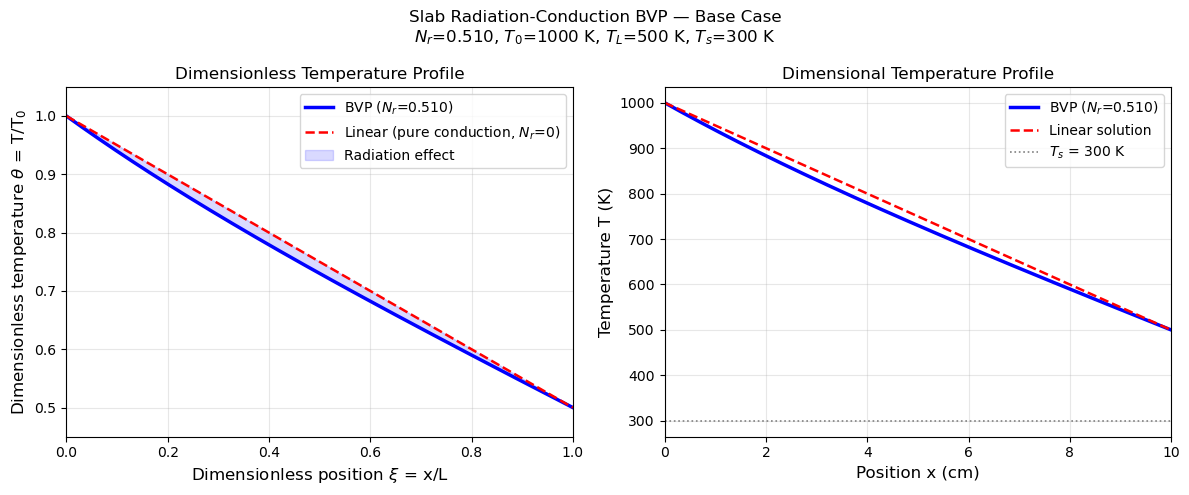

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06\figs\fig01_base_case.png


In [4]:
# ======================================================
# 基準案例求解（Nr=0.510, θ₁=0.5, θ_s=0.3）
# ======================================================
xi_init = np.linspace(0.0, 1.0, 80)

# 線性初始猜測
theta_g  = 1.0 + (theta1 - 1.0) * xi_init
dtheta_g = np.full_like(xi_init, theta1 - 1.0)
y_init   = np.array([theta_g, dtheta_g])

sol = solve_bvp(make_ode(Nr, theta_s),
                make_bc(th0=1.0, th1=theta1),
                xi_init, y_init,
                tol=1e-5, max_nodes=5000)

print(f"求解狀態  : {'成功 ✓' if sol.success else '失敗 ✗'}")
print(f"自適應節點: {sol.x.size}")
print(f"最大殘差  : {sol.rms_residuals.max():.2e}")

# 計算解曲線
xi_dense    = np.linspace(0.0, 1.0, 300)
theta_bvp   = sol.sol(xi_dense)[0]         # 無因次溫度
T_bvp       = T0 * theta_bvp               # 維度溫度 (K)
T_lin_dense = T0 * (1.0 + (theta1-1.0)*xi_dense)

print(f"\n  θ(ξ=0.5) 純傳導（線性）= {1.0+(theta1-1.0)*0.5:.4f}  "
      f"| T = {T0*(1.0+(theta1-1.0)*0.5):.1f} K")
print(f"  θ(ξ=0.5) 含輻射（BVP） = {sol.sol(np.array([0.5]))[0][0]:.4f}  "
      f"| T = {T0*sol.sol(np.array([0.5]))[0][0]:.1f} K")

# ======================================================
# fig01：無因次溫度剖面 + 維度溫度剖面
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 左圖：無因次溫度 ---
ax1 = axes[0]
ax1.plot(xi_dense, theta_bvp, 'b-', lw=2.5, label=f'BVP ($N_r$={Nr:.3f})')
ax1.plot(xi_dense, 1.0+(theta1-1.0)*xi_dense, 'r--', lw=1.8,
         label='Linear (pure conduction, $N_r$=0)')
ax1.fill_between(xi_dense,
                 1.0+(theta1-1.0)*xi_dense, theta_bvp,
                 alpha=0.15, color='blue', label='Radiation effect')
ax1.set_xlabel('Dimensionless position $\\xi$ = x/L')
ax1.set_ylabel('Dimensionless temperature $\\theta$ = T/T$_0$')
ax1.set_title('Dimensionless Temperature Profile')
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0.45, 1.05)

# --- 右圖：維度溫度 ---
ax2 = axes[1]
x_dense = xi_dense * L * 100  # 轉換為 cm
ax2.plot(x_dense, T_bvp, 'b-', lw=2.5, label=f'BVP ($N_r$={Nr:.3f})')
ax2.plot(x_dense, T_lin_dense, 'r--', lw=1.8, label='Linear solution')
ax2.axhline(Ts, color='gray', ls=':', lw=1.2, label=f'$T_s$ = {Ts:.0f} K')
ax2.set_xlabel('Position x (cm)')
ax2.set_ylabel('Temperature T (K)')
ax2.set_title('Dimensional Temperature Profile')
ax2.legend()
ax2.set_xlim(0, L*100)

fig.suptitle(f'Slab Radiation-Conduction BVP — Base Case\n'
             f'$N_r$={Nr:.3f}, $T_0$={T0:.0f} K, $T_L$={TL:.0f} K, $T_s$={Ts:.0f} K',
             fontsize=12)
plt.tight_layout()
fig_path1 = str(FIG_DIR / 'fig01_base_case.png')
plt.savefig(fig_path1, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path1}")

---
### 4. 輻射–傳導參數 $N_r$ 之敏感度分析 <a id="4"></a>

$N_r = \varepsilon\sigma_{\text{SB}}T_0^3 L^2/k$ 綜合反映了三類物理效應：

| 增大 $N_r$ 的方式 | 工程意義 |
|-----------------|---------|
| 提高 $T_0$（高溫操作） | 輻射強度以 $T^4$ 急劇增長 |
| 增大 $L$（厚壁）| 橫跨更長距離，輻射效應積累 |
| 減小 $k$（低導熱材料）| 傳導減弱，輻射相對重要性增加 |
| 增大 $\varepsilon$（高輻射面）| 輻射散熱量直接倍增 |

本節固定 $\theta_1=0.5$ 、 $\theta_s=0.3$ ，改變 $N_r \in \{0, 0.25, 0.5, 1.0, 2.0, 4.0\}$ ：


    Nr |   θ(0.5) |   Nodes | Status
---------------------------------------------
  0.00 |   0.7500 | analytic | analytical ✓
  0.25 |   0.7397 |      80 | ✓
  0.50 |   0.7304 |      80 | ✓
  1.00 |   0.7137 |      80 | ✓
  2.00 |   0.6864 |      80 | ✓
  4.00 |   0.6463 |      80 | ✓


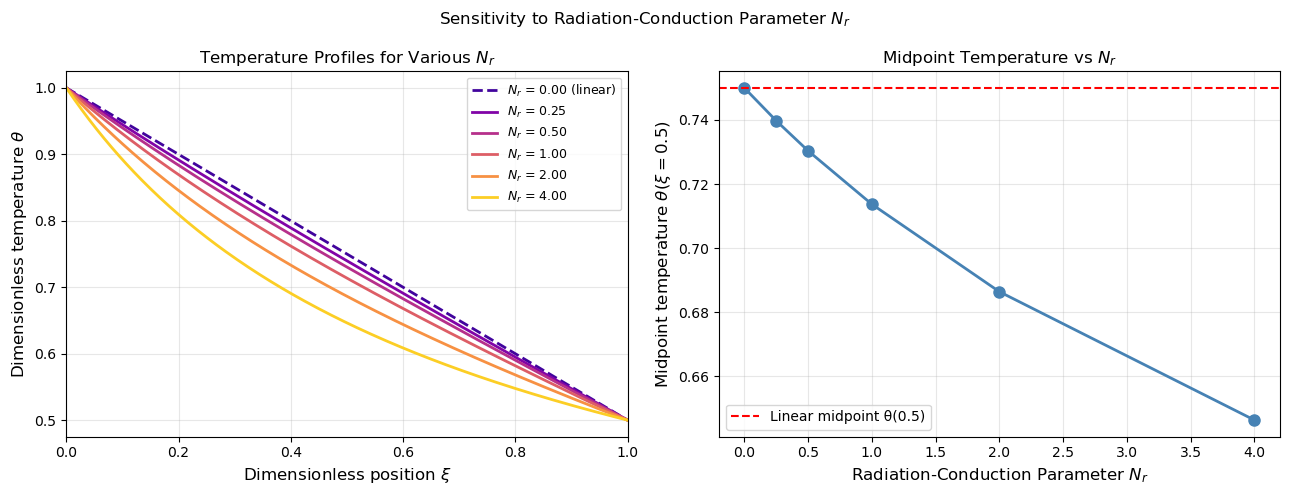

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06\figs\fig02_Nr_sensitivity.png


In [5]:
# ======================================================
# Nr 敏感度分析
# ======================================================
Nr_list      = [0.0, 0.25, 0.50, 1.0, 2.0, 4.0]
colors_nr    = plt.cm.plasma(np.linspace(0.1, 0.9, len(Nr_list)))

Nr_results   = []   # [(Nr, theta_mid, nodes)]

xi_dense = np.linspace(0.0, 1.0, 300)

print(f"{'Nr':>6} | {'θ(0.5)':>8} | {'Nodes':>7} | Status")
print("-" * 45)

for Nr_v, c_v in zip(Nr_list, colors_nr):
    xi_i     = np.linspace(0, 1, 80)
    theta_g  = 1.0 + (theta1-1.0) * xi_i
    dtheta_g = np.full_like(xi_i, theta1-1.0)
    y_i      = np.array([theta_g, dtheta_g])

    if Nr_v == 0.0:
        # 純傳導：解析解
        theta_mid = 1.0 + (theta1-1.0)*0.5
        Nr_results.append((Nr_v, theta_mid, 0, True,
                           1.0 + (theta1-1.0)*xi_dense))
        print(f"{Nr_v:>6.2f} | {theta_mid:>8.4f} | {'analytic':>7} | analytical ✓")
    else:
        sol_i = solve_bvp(make_ode(Nr_v, theta_s),
                          make_bc(th0=1.0, th1=theta1),
                          xi_i, y_i,
                          tol=1e-5, max_nodes=5000)
        theta_mid = float(sol_i.sol(np.array([0.5]))[0])
        Nr_results.append((Nr_v, theta_mid, sol_i.x.size, sol_i.success,
                           sol_i.sol(xi_dense)[0]))
        print(f"{Nr_v:>6.2f} | {theta_mid:>8.4f} | {sol_i.x.size:>7} | "
              f"{'✓' if sol_i.success else '✗'}")

# ======================================================
# fig02：Nr 敏感度比較圖
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：各 Nr 的溫度剖面
ax = axes[0]
for (Nr_v, _, _, ok, theta_c), c_v in zip(Nr_results, colors_nr):
    lbl = f'$N_r$ = {Nr_v:.2f}' + (' (linear)' if Nr_v == 0 else '')
    ls  = '--' if Nr_v == 0 else '-'
    ax.plot(xi_dense, theta_c, color=c_v, lw=2.0, ls=ls, label=lbl)
ax.set_xlabel('Dimensionless position $\\xi$')
ax.set_ylabel('Dimensionless temperature $\\theta$')
ax.set_title('Temperature Profiles for Various $N_r$')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# 右圖：中心θ vs Nr
ax2 = axes[1]
Nr_vals   = [r[0] for r in Nr_results]
theta_mid = [r[1] for r in Nr_results]
ax2.plot(Nr_vals, theta_mid, 'o-', color='steelblue', lw=2.0, ms=8)
ax2.axhline(1.0+(theta1-1.0)*0.5, color='r', ls='--', lw=1.5,
            label='Linear midpoint θ(0.5)')
ax2.set_xlabel('Radiation-Conduction Parameter $N_r$')
ax2.set_ylabel('Midpoint temperature $\\theta(\\xi=0.5)$')
ax2.set_title('Midpoint Temperature vs $N_r$')
ax2.legend()

fig.suptitle('Sensitivity to Radiation-Conduction Parameter $N_r$',
             fontsize=12)
plt.tight_layout()
fig_path2 = str(FIG_DIR / 'fig02_Nr_sensitivity.png')
plt.savefig(fig_path2, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path2}")

---
### 5. 邊界溫度對溫度分布的影響 <a id="5"></a>

固定 $N_r = 0.5103$ 、 $T_0 = 1000$ K、 $T_s = 300$ K（ $\theta_s=0.3$ ），
改變右端溫度 $T_L$ ，考察 $\theta_1 \in \{0.3, 0.4, 0.5, 0.6, 0.7, 0.9\}$ ：

- $\theta_1 < 1$ ：右端較冷，溫度由左向右下降
- $\theta_1 = 1$ ：兩端同溫，對稱問題，中心溫度最低（輻射冷卻效應）
- $\theta_1 < \theta_s$ ：右端溫度低於環境，右側可能出現輻射加熱效應（右側 $T < T_s$ ）


    θ₁ |   TL (K) |   θ(0.5) | Nodes | Status
-------------------------------------------------------
  0.30 |    300.0 |   0.6367 |    80 | ✓
  0.40 |    400.0 |   0.6837 |    80 | ✓
  0.50 |    500.0 |   0.7300 |    80 | ✓
  0.60 |    600.0 |   0.7755 |    80 | ✓
  0.70 |    700.0 |   0.8200 |    80 | ✓
  0.90 |    900.0 |   0.9060 |    80 | ✓


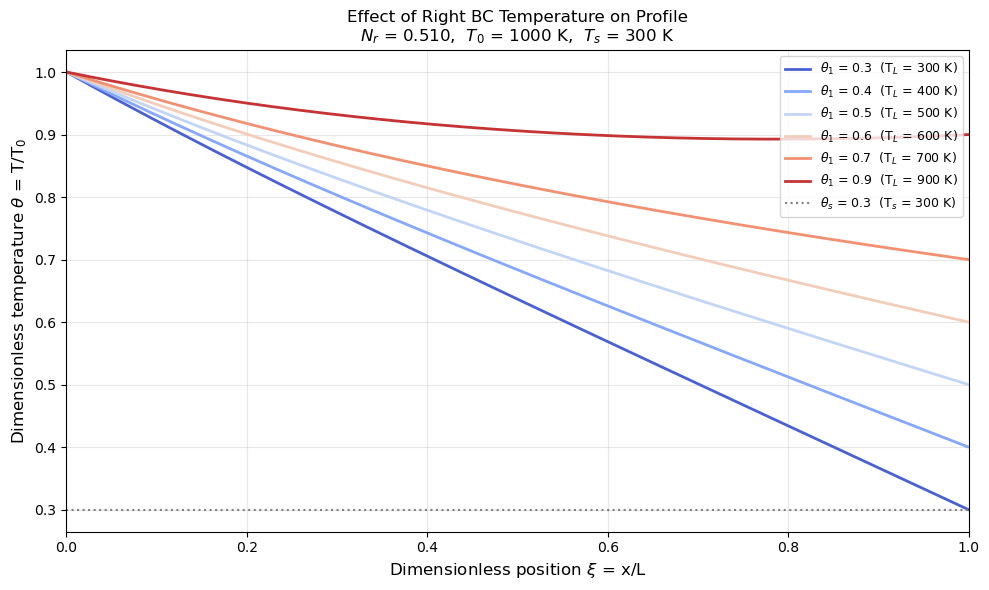

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06\figs\fig03_BC_sensitivity.png


In [6]:
# ======================================================
# 邊界溫度 θ₁ 敏感度分析（固定 Nr=Nr_base）
# ======================================================
theta1_list = [0.3, 0.4, 0.5, 0.6, 0.7, 0.9]
colors_bc   = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(theta1_list)))

bc_results  = []   # [(θ1, theta_mid, nodes)]
xi_dense    = np.linspace(0.0, 1.0, 300)

print(f"{'θ₁':>6} | {'TL (K)':>8} | {'θ(0.5)':>8} | Nodes | Status")
print("-" * 55)

for th1_v, c_v in zip(theta1_list, colors_bc):
    xi_i     = np.linspace(0, 1, 80)
    theta_g  = 1.0 + (th1_v - 1.0) * xi_i
    dtheta_g = np.full_like(xi_i, th1_v - 1.0)
    y_i      = np.array([theta_g, dtheta_g])

    sol_i = solve_bvp(make_ode(Nr, theta_s),
                      make_bc(th0=1.0, th1=th1_v),
                      xi_i, y_i,
                      tol=1e-5, max_nodes=5000)
    theta_mid = float(sol_i.sol(np.array([0.5]))[0])
    bc_results.append((th1_v, theta_mid, sol_i.x.size, sol_i.success,
                       sol_i.sol(xi_dense)[0]))
    print(f"{th1_v:>6.2f} | {T0*th1_v:>8.1f} | {theta_mid:>8.4f} | "
          f"{sol_i.x.size:>5} | {'✓' if sol_i.success else '✗'}")

# ======================================================
# fig03：邊界溫度敏感度
# ======================================================
fig, ax = plt.subplots(figsize=(10, 6))

for (th1_v, _, _, ok, theta_c), c_v in zip(bc_results, colors_bc):
    lbl = f'$\\theta_1$ = {th1_v:.1f}  (T$_L$ = {T0*th1_v:.0f} K)'
    ax.plot(xi_dense, theta_c, color=c_v, lw=2.0, label=lbl)

# 標記 θ_s 水平線
ax.axhline(theta_s, color='gray', ls=':', lw=1.5,
           label=f'$\\theta_s$ = {theta_s:.1f}  (T$_s$ = {Ts:.0f} K)')

ax.set_xlabel('Dimensionless position $\\xi$ = x/L')
ax.set_ylabel('Dimensionless temperature $\\theta$ = T/T$_0$')
ax.set_title(f'Effect of Right BC Temperature on Profile\n'
             f'$N_r$ = {Nr:.3f},  $T_0$ = {T0:.0f} K,  $T_s$ = {Ts:.0f} K')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1)

plt.tight_layout()
fig_path3 = str(FIG_DIR / 'fig03_BC_sensitivity.png')
plt.savefig(fig_path3, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path3}")

---
### 6. 大 $N_r$ 下初始猜測值的收斂性分析 <a id="6"></a>

非線性 BVP 的求解對**初始猜測值**十分敏感。當 $N_r$ 較大時（例如 $N_r=4$ ），
不良的初始猜測可能導致求解器無法收斂或收斂至錯誤解。

本節以 $N_r = 4.0$ 為例，比較以下四種初始猜測策略：

| 策略 | 初始 $\theta(\xi)$ 函式 | 說明 |
|------|----------------------|------|
| 線性插值 | $1 + (\theta_1-1)\xi$ | 最直觀（對應純傳導解）|
| 左端常數 | $1.0$（恆為 1）| 過高估計 |
| 右端常數 | $\theta_1$（恆為 0.5）| 過低估計 |
| 凹形拋物線 | $1-(1-\theta_1)(2\xi-\xi^2)$ | 反映輻射冷卻趨勢 |

> **預期結果**：線性插值與凹形拋物線應可收斂；常數猜測可能需要更多節點或失敗。


Nr = 4.0  (大輻射效應測試)
Strategy                  |   θ(0.5) | Nodes | Status | MaxResidual
----------------------------------------------------------------------
Linear (θ₁ interp)        |   0.6463 |   100 | ✓      | 1.45e-06
Constant high (θ=1.0)     |   0.6463 |   190 | ✓      | 1.45e-06
Constant low (θ=θ₁)       |   0.6463 |   100 | ✓      | 4.61e-05
Concave parabola          |   0.6463 |   100 | ✓      | 3.26e-06


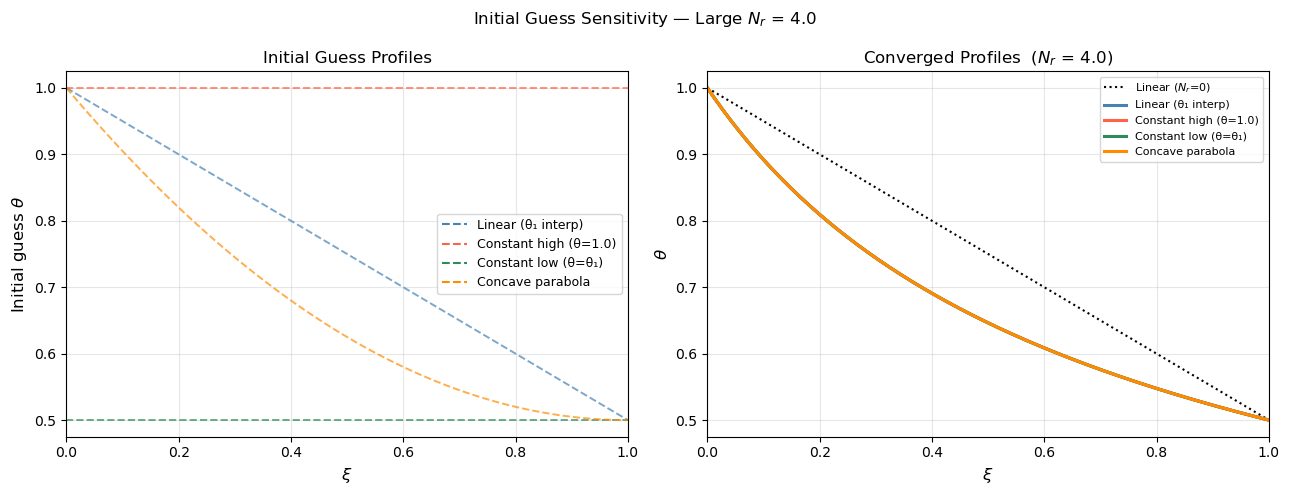

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_06\figs\fig04_initial_guess.png


In [7]:
# ======================================================
# 大 Nr 下初始猜測值收斂性比較（Nr = 4.0）
# ======================================================
Nr_large = 4.0
xi_i     = np.linspace(0.0, 1.0, 100)
xi_dense = np.linspace(0.0, 1.0, 300)

# 四種初始猜測定義
guess_defs = {
    'Linear (θ₁ interp)' : {
        'theta' : 1.0 + (theta1-1.0)*xi_i,
        'dtheta': np.full_like(xi_i, theta1-1.0),
    },
    'Constant high (θ=1.0)' : {
        'theta' : np.ones_like(xi_i),
        'dtheta': np.zeros_like(xi_i),
    },
    'Constant low (θ=θ₁)' : {
        'theta' : np.full_like(xi_i, theta1),
        'dtheta': np.zeros_like(xi_i),
    },
    'Concave parabola' : {
        'theta' : 1.0 - (1.0-theta1)*(2*xi_i - xi_i**2),
        'dtheta': -(1.0-theta1)*(2 - 2*xi_i),
    },
}

print(f"Nr = {Nr_large}  (大輻射效應測試)")
print(f"{'Strategy':<25} | {'θ(0.5)':>8} | Nodes | Status | MaxResidual")
print("-" * 70)

ig_results = {}
for name, gd in guess_defs.items():
    y_i   = np.array([gd['theta'], gd['dtheta']])
    sol_i = solve_bvp(make_ode(Nr_large, theta_s),
                      make_bc(th0=1.0, th1=theta1),
                      xi_i.copy(), y_i.copy(),
                      tol=1e-4, max_nodes=10000)
    theta_mid = float(sol_i.sol(np.array([0.5]))[0]) if sol_i.success else float('nan')
    max_res   = sol_i.rms_residuals.max() if sol_i.success else float('nan')
    ig_results[name] = (sol_i, theta_mid, gd)
    print(f"{name:<25} | {theta_mid:>8.4f} | {sol_i.x.size:>5} | "
          f"{'✓' if sol_i.success else '✗':<6} | {max_res:.2e}")

# ======================================================
# fig04：初始猜測比較圖
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_ig = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# 左圖：各初始猜測函式
ax = axes[0]
for (name, (sol_i, _, gd)), c in zip(ig_results.items(), colors_ig):
    ax.plot(xi_i, gd['theta'], c=c, ls='--', lw=1.4, alpha=0.7)
    # label only
ax.set_xlabel('$\\xi$')
ax.set_ylabel('Initial guess $\\theta$')
ax.set_title('Initial Guess Profiles')
# add dummy for legend
for (name, _), c, ls in zip(ig_results.items(), colors_ig,
                             ['--']*4):
    ax.plot([], [], c=c, ls=ls, label=name)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# 右圖：收斂後的溫度剖面
ax2 = axes[1]
# 線性解參考
ax2.plot(xi_dense, 1.0+(theta1-1.0)*xi_dense, 'k:', lw=1.5,
         label='Linear ($N_r$=0)')
for (name, (sol_i, _, gd)), c in zip(ig_results.items(), colors_ig):
    if sol_i.success:
        ax2.plot(xi_dense, sol_i.sol(xi_dense)[0],
                 c=c, lw=2.2, label=f'{name}')
    else:
        ax2.plot([], [], c=c, label=f'{name} (FAILED)')
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\theta$')
ax2.set_title(f'Converged Profiles  ($N_r$ = {Nr_large})')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1)

fig.suptitle(f'Initial Guess Sensitivity — Large $N_r$ = {Nr_large}', fontsize=12)
plt.tight_layout()
fig_path4 = str(FIG_DIR / 'fig04_initial_guess.png')
plt.savefig(fig_path4, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path4}")

---
### 7. 課程重點整理 <a id="7"></a>

#### 7.1 數值求解設定

| 設定項目 | 值 | 說明 |
|---------|-----|------|
| 初始猜測 | 線性插值 $\theta=1+(\theta_1-1)\xi$ | 對 $N_r \lesssim 4$ 均可收斂 |
| 求解器容忍度 | `tol=1e-5` | 基準至 §5 的求解精度 |
| 大 $N_r$ 容忍度 | `tol=1e-4` | §6 大 $N_r$ 案例 |
| 最大節點數 | `max_nodes=5000–10000` | 依問題規模調整 |

#### 7.2 基準案例結果（ $N_r=0.5103$ ，80 個自適應節點）

| 量 | 純傳導（線性）| 含輻射（BVP）| 差異 |
|----|------------|------------|------|
| $\theta(0.5)$ | 0.7500 | **0.7300** | $-0.0200$（ $-2.7\%$ ）|
| $T(x=L/2)$ | 750 K | **730 K** | $-20$ K |
| 最大殘差 | — | 9.02×10⁻⁸ | — |

#### 7.3 $N_r$ 敏感度（固定 $\theta_1=0.5$ ， $\theta_s=0.3$ ）

| $N_r$ | $\theta(0.5)$ | 節點數 | 說明 |
|--------|------------|--------|------|
| 0.00 | 0.7500 | analytic | 純傳導（線性解析解）✓ |
| 0.25 | 0.7397 | 80 | 輻射效應已可見 |
| 0.50 | 0.7304 | 80 | 基準案例（ $N_r\approx0.5103$ ，接近此值）|
| 1.00 | 0.7137 | 80 | 明顯偏離線性 |
| 2.00 | 0.6864 | 80 | 強輻射效應 |
| 4.00 | 0.6463 | 80 | 極強輻射效應 |

#### 7.4 初始猜測收斂性（ $N_r = 4.0$ ）

| 策略 | $\theta(0.5)$ | 節點數 | 最大殘差 |
|------|------------|--------|---------|
| 線性插值 | 0.6463 | 100 | 1.45×10⁻⁶ |
| 常數高（θ=1.0）| 0.6463 | 190 | 1.45×10⁻⁶ |
| 常數低（θ=θ₁）| 0.6463 | 100 | 4.61×10⁻⁵ |
| 凹形拋物線 | 0.6463 | 100 | 3.26×10⁻⁶ |

> **結論**：四種初始猜測全部收斂至相同解（解的唯一性）。常數高猜測需 190 個節點（較多），但最終結果相同。

#### 7.5 物理規律

- $N_r$ **增大**：輻射效應增強，溫度剖面越偏離線性，中心溫度越低（剖面越凹）
- $N_r \to 0$ ：數值解趨近線性解析解（驗算 ✓）
- **右端溫度降低**（ $\theta_1$ 減小）：若 $\theta_1 = \theta_s$ （右端溫度等於環境溫度），輻射效應在右側消失
- **解的唯一性**：對本問題（兩端 Dirichlet BCs + 單調遞增非線性項），解是唯一的，不同初始猜測均收斂至同一結果

---

> **課程資訊**
> - 課程名稱：電腦在化工上之應用 (ChemE 3502)
> - 課程單元：Unit09 邊界值問題 — 範例 06：伴有輻射之平板穩態熱傳溫度分布
> - 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
> - 授課教師：莊曜禎 助理教授
> - 更新日期：2026-02-22
>
> **課程授權 [CC BY-NC-SA 4.0]**  
> 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
